In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("ML Notebook Ready")


ML Notebook Ready


In [2]:
df = pd.read_csv("../data/processed/economic_data.csv")

df["DATE"] = pd.to_datetime(df["DATE"])

df.head()

,DATE,Consumer_Sentiment,CPI,Federal_Funds_Rate,Housing_Starts,Industrial_Production,Real_GDP,Recession,Treasury_10Y,Treasury_2Y,Unemployment
0,1854-12-01,86.2,21.48,0.8,1657.0,4.8739,2182.681,1.0,2.83,7.06,3.4
1,1855-01-01,86.2,21.48,0.8,1657.0,4.8739,2182.681,0.0,2.83,7.06,3.4
2,1855-02-01,86.2,21.48,0.8,1657.0,4.8739,2182.681,0.0,2.83,7.06,3.4
3,1855-03-01,86.2,21.48,0.8,1657.0,4.8739,2182.681,0.0,2.83,7.06,3.4
4,1855-04-01,86.2,21.48,0.8,1657.0,4.8739,2182.681,0.0,2.83,7.06,3.4


In [3]:
# Features
features = [
    "Unemployment",
    "CPI",
    "Industrial_Production",
    "Federal_Funds_Rate",
    "Treasury_10Y",
    "Treasury_2Y",
    "Real_GDP",
    "Housing_Starts",
    "Consumer_Sentiment"
]

X = df[features]

# Target
y = df["Recession"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (2061, 9)
Target Shape: (2061,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (1648, 9)
Testing : (413, 9)


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed")

Scaling completed


In [6]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:",
      round(accuracy_score(y_test, log_pred), 4))

Logistic Regression Accuracy: 0.7433


In [7]:
tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree Accuracy:",
      round(accuracy_score(y_test, tree_pred), 4))

Decision Tree Accuracy: 0.7433


In [8]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      round(accuracy_score(y_test, rf_pred), 4))

Random Forest Accuracy: 0.7506


In [9]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, tree_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, tree_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, tree_pred),
        f1_score(y_test, rf_pred)
    ]
})

results.round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.743,1.000,0.086,0.159
1,Decision Tree,0.743,0.656,0.181,0.284
2,Random Forest,0.751,0.638,0.259,0.368


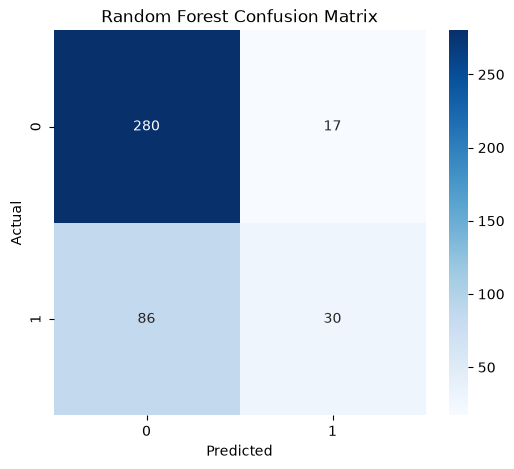

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


In [11]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

         0.0       0.77      0.94      0.84       297
         1.0       0.64      0.26      0.37       116

    accuracy                           0.75       413
   macro avg       0.70      0.60      0.61       413
weighted avg       0.73      0.75      0.71       413



In [12]:
import joblib
from pathlib import Path

model_path = Path("../models")
model_path.mkdir(parents=True, exist_ok=True)

joblib.dump(rf_model, model_path / "recession_model.pkl")
joblib.dump(scaler, model_path / "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
